In [3]:
x_value = (2.5 + 1.1 + 6.7 + 4.3 + 3.9) / 5
print(x_value)

y_value = (3.8 + 5.4 + 2.2 + 7.5 + 1.6) / 5
print(y_value)

3.7
4.1


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

k = 1

def wcss(data, assigned_cluster, centroids):
    total_distance = 0
    for i in range(k):
        cluster_points = data[assigned_cluster == i]
        if len(cluster_points) > 0:
            distances = np.sum((cluster_points - centroids[i]) ** 2, axis=1)
            total_distance += np.sum(distances)
    return total_distance

In [5]:
print(wcss(np.array([[2.5, 3.8], [1.1, 5.4], [6.7, 2.2], [4.3, 7.5], [3.9, 1.6]]), np.array([0, 0, 0, 0, 0]), np.array([[x_value, y_value]])))

40.800000000000004


In [11]:
data = pd.read_csv("https://raw.githubusercontent.com/drolsonmi/math3080/refs/heads/main/Datasets/KMeans_data.csv", header=None, names=['x', 'y'])
data.head()

,x,y
0,11.549,7.939
1,11.013,1.845
2,-8.027,-2.843
3,10.736,5.339
4,-4.335,6.580


In [14]:
def visualize_clusters(data, assigned_cluster, centroids):
    plt.figure()
    colors = ['red', 'green', 'blue', 'cyan', 'magenta', 'yellow', 'black', 'orange', 'purple', 'brown']
    for i in range(k):
        cluster_points = data[assigned_cluster == i]
        if len(cluster_points) > 0:
            plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=colors[i], label=f'Cluster {i+1}', alpha=0.6)
        plt.scatter(centroids[i][0], centroids[i][1], c=colors[i], marker='X', edgecolors='black', s=100)

    plt.title("Three Random Clusters in 2D")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.show()

def euclidean_distance(point, centroids):
    return np.sqrt(np.sum((point - centroids) ** 2, axis=1))

def assign_clusters(data, centroids):
    new_cluster = np.zeros(len(data), dtype=int)
    for i, point in enumerate(data):
        distances = euclidean_distance(point, centroids)
        new_cluster[i] = np.argmin(distances)
    return new_cluster

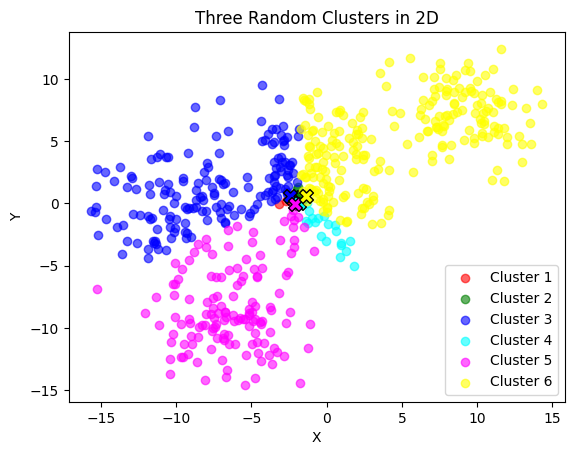

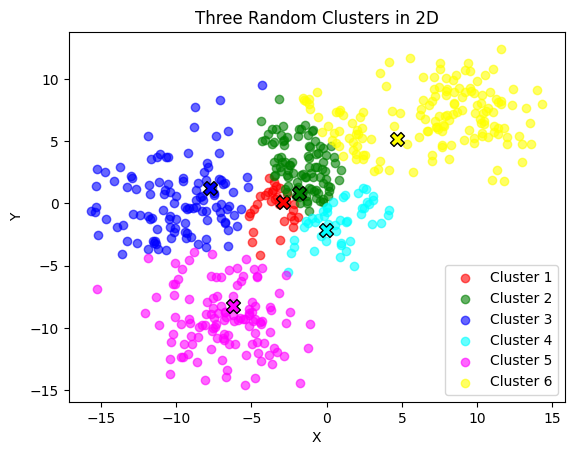

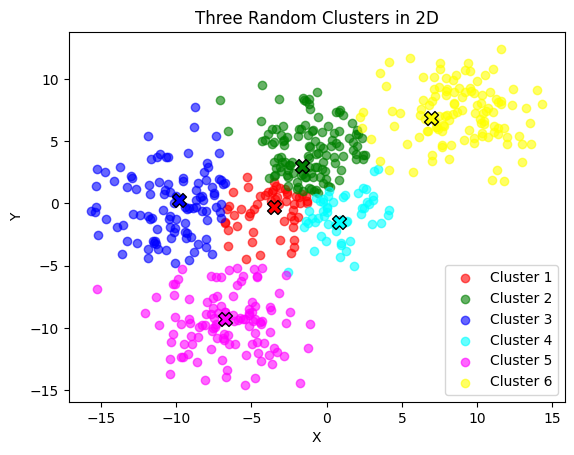

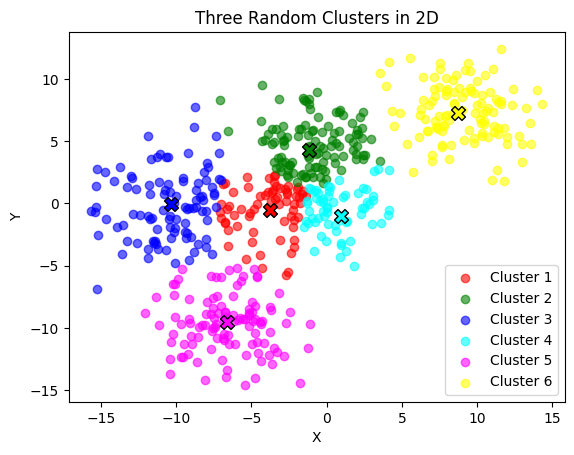

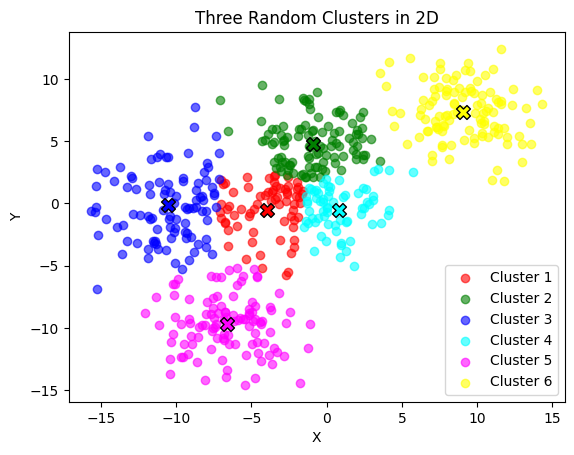

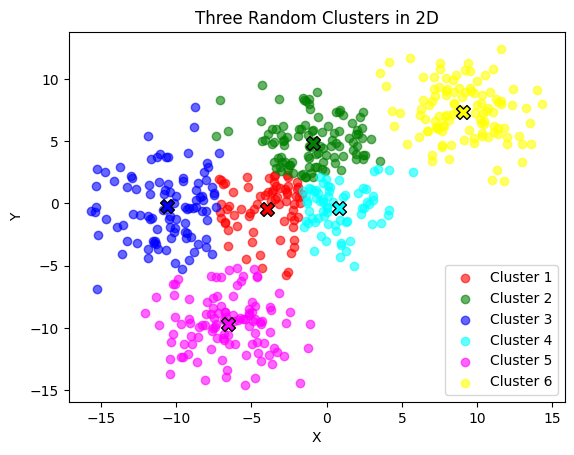

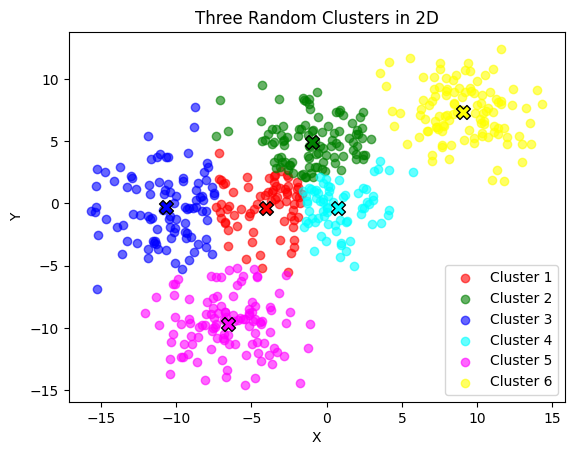

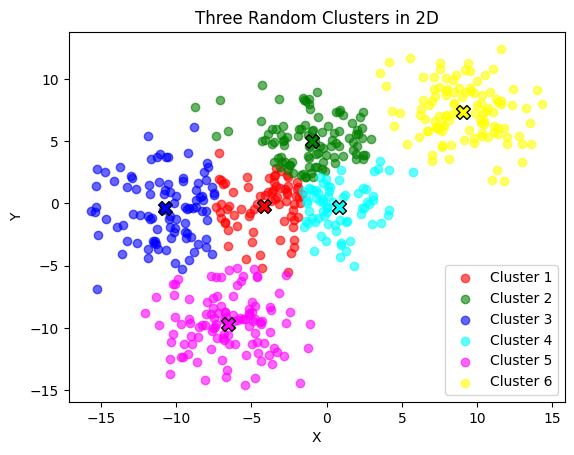

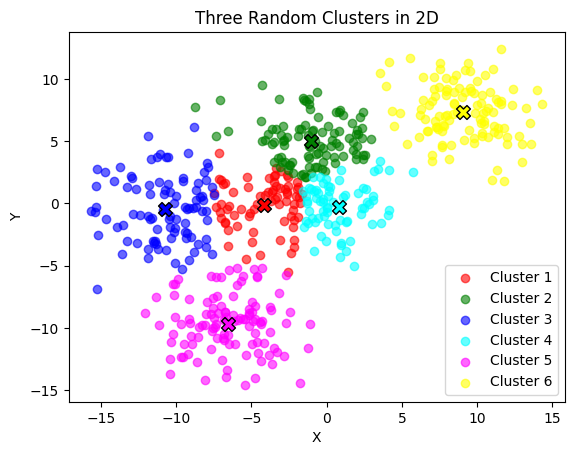

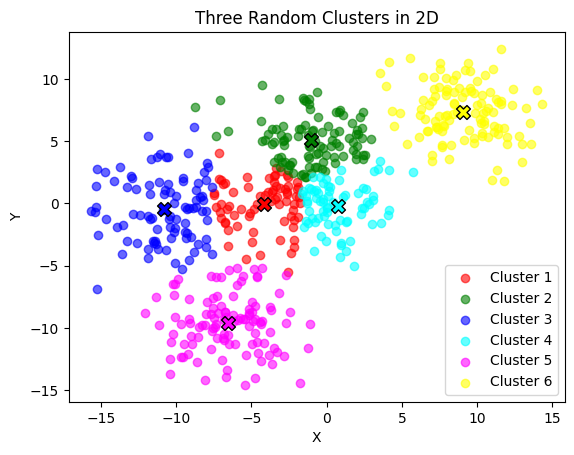

Cluster 1 has 73 points.
Cluster 2 has 100 points.
Cluster 3 has 93 points.
Cluster 4 has 73 points.
Cluster 5 has 111 points.
Cluster 6 has 110 points.


In [19]:
k = 6
np.random.seed(113)

# Step 2
assigned_cluster = np.random.randint(0, k, size=len(data))


for i in range(10):
    # Step 3
    points = data[['x', 'y']].values
    centroids = []
    for i in range(k):
        cluster_points = points[assigned_cluster == i]
        centroids.append(cluster_points.mean(axis=0))

    # Step 4
    assigned_cluster = assign_clusters(points, centroids)

    # Step 5
    visualize_clusters(points, assigned_cluster, centroids)

for i in range(k):
    cluster_points_count = np.sum(assigned_cluster == i)
    print(f"Cluster {i+1} has {cluster_points_count} points.")




In [20]:
wccs_value = wcss(points, assigned_cluster, centroids)
print(f"WCSS value: {wccs_value}")

WCSS value: 5170.086471244468


In [21]:
wccs_values = []
for i in range (1, 11):
    k = i
    np.random.seed(113)

    # Step 2
    assigned_cluster = np.random.randint(0, k, size=len(data))


    for i in range(10):
        # Step 3
        points = data[['x', 'y']].values
        centroids = []
        for i in range(k):
            cluster_points = points[assigned_cluster == i]
            centroids.append(cluster_points.mean(axis=0))

        # Step 4
        assigned_cluster = assign_clusters(points, centroids)

    # Step 5
    # visualize_clusters(points, assigned_cluster, centroids)
    wccs_value = wcss(points, assigned_cluster, centroids)
    wccs_values.append(wccs_value)
    print(f"WCSS value for k={k}: {wccs_value}")






WCSS value for k=1: 47963.853046382144
WCSS value for k=2: 21094.334966683324
WCSS value for k=3: 12313.177812206735
WCSS value for k=4: 7105.537233725225
WCSS value for k=5: 5676.3474186590665
WCSS value for k=6: 5170.086471244468
WCSS value for k=7: 4783.986363854904
WCSS value for k=8: 4308.523613839611
WCSS value for k=9: 3867.890906020618
WCSS value for k=10: 3415.460793998259


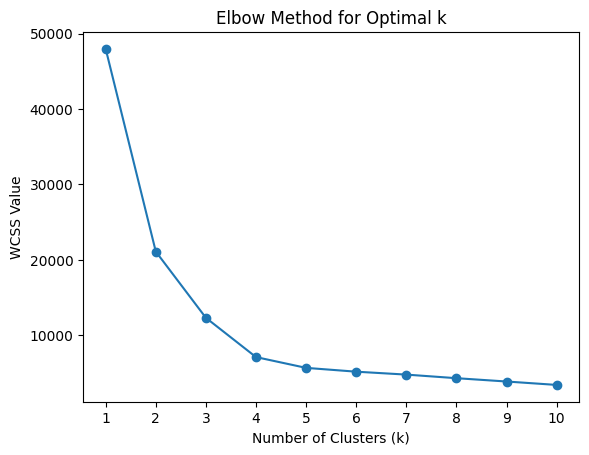

In [23]:
k = [i for i in range(1, 11)]
elbow_figure = plt.figure()
plt.plot(k, wccs_values, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS Value")
plt.xticks(k)
plt.show()
